In [1]:
import pandas as pd
import re
from pathlib import Path

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "liar"

columns = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "job_title",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context"
]

# Load the LIAR splits
train_df = pd.read_csv(
    DATA_DIR / "train.tsv",
    sep="\t",
    header=None,
    names=columns
)

valid_df = pd.read_csv(
    DATA_DIR / "valid.tsv",
    sep="\t",
    header=None,
    names=columns
)

test_df = pd.read_csv(
    DATA_DIR / "test.tsv",
    sep="\t",
    header=None,
    names=columns
)

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

Train: (10240, 14)
Validation: (1284, 14)
Test: (1267, 14)


In [2]:
def clean_text(text):
    """
    Basic text normalization for the baseline model.
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text

In [3]:
train_df["clean_statement"] = train_df["statement"].apply(clean_text)
valid_df["clean_statement"] = valid_df["statement"].apply(clean_text)
test_df["clean_statement"] = test_df["statement"].apply(clean_text)

print(train_df[["statement", "clean_statement"]].head(5))

                                           statement  \
0  Says the Annies List political group supports ...   
1  When did the decline of coal start? It started...   
2  Hillary Clinton agrees with John McCain "by vo...   
3  Health care reform legislation is likely to ma...   
4  The economic turnaround started at the end of ...   

                                     clean_statement  
0  says the annies list political group supports ...  
1  when did the decline of coal start? it started...  
2  hillary clinton agrees with john mccain "by vo...  
3  health care reform legislation is likely to ma...  
4  the economic turnaround started at the end of ...  


In [4]:
print("Empty training statements:",
      (train_df["clean_statement"] == "").sum())

print("Empty validation statements:",
      (valid_df["clean_statement"] == "").sum())

print("Empty test statements:",
      (test_df["clean_statement"] == "").sum())

Empty training statements: 0
Empty validation statements: 0
Empty test statements: 0


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [6]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train = tfidf.fit_transform(train_df["clean_statement"])

X_valid = tfidf.transform(valid_df["clean_statement"])

X_test = tfidf.transform(test_df["clean_statement"])

y_train = train_df["label"]
y_valid = valid_df["label"]
y_test = test_df["label"]

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape:", X_test.shape)

X_train shape: (10240, 20000)
X_valid shape: (1284, 20000)
X_test shape: (1267, 20000)


In [7]:
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

print("Baseline model training completed.")

Baseline model training completed.


In [8]:
y_valid_pred = model.predict(X_valid)
y_test_pred = model.predict(X_test)

print("Validation predictions generated.")
print("Test predictions generated.")

Validation predictions generated.
Test predictions generated.


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

valid_accuracy = accuracy_score(y_valid, y_valid_pred)

valid_precision = precision_score(
    y_valid,
    y_valid_pred,
    average="macro",
    zero_division=0
)

valid_recall = recall_score(
    y_valid,
    y_valid_pred,
    average="macro",
    zero_division=0
)

valid_f1 = f1_score(
    y_valid,
    y_valid_pred,
    average="macro",
    zero_division=0
)

print("Validation Accuracy :", round(valid_accuracy, 4))
print("Validation Precision:", round(valid_precision, 4))
print("Validation Recall   :", round(valid_recall, 4))
print("Validation Macro F1 :", round(valid_f1, 4))

Validation Accuracy : 0.2469
Validation Precision: 0.2464
Validation Recall   : 0.2588
Validation Macro F1 : 0.2487


In [10]:
print(
    classification_report(
        y_valid,
        y_valid_pred,
        labels=[
            "pants-fire",
            "false",
            "barely-true",
            "half-true",
            "mostly-true",
            "true"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  pants-fire       0.23      0.35      0.28       116
       false       0.26      0.22      0.23       263
 barely-true       0.22      0.19      0.20       237
   half-true       0.28      0.25      0.27       248
 mostly-true       0.28      0.24      0.26       251
        true       0.21      0.30      0.25       169

    accuracy                           0.25      1284
   macro avg       0.25      0.26      0.25      1284
weighted avg       0.25      0.25      0.25      1284



In [11]:
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

print("Test Accuracy :", round(test_accuracy, 4))
print("Test Precision:", round(test_precision, 4))
print("Test Recall   :", round(test_recall, 4))
print("Test Macro F1 :", round(test_f1, 4))

Test Accuracy : 0.2541
Test Precision: 0.2519
Test Recall   : 0.2623
Test Macro F1 : 0.2517


In [12]:
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=[
            "pants-fire",
            "false",
            "barely-true",
            "half-true",
            "mostly-true",
            "true"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  pants-fire       0.17      0.33      0.22        92
       false       0.32      0.29      0.31       249
 barely-true       0.26      0.23      0.24       212
   half-true       0.28      0.22      0.24       265
 mostly-true       0.24      0.22      0.23       241
        true       0.25      0.29      0.27       208

    accuracy                           0.25      1267
   macro avg       0.25      0.26      0.25      1267
weighted avg       0.26      0.25      0.26      1267



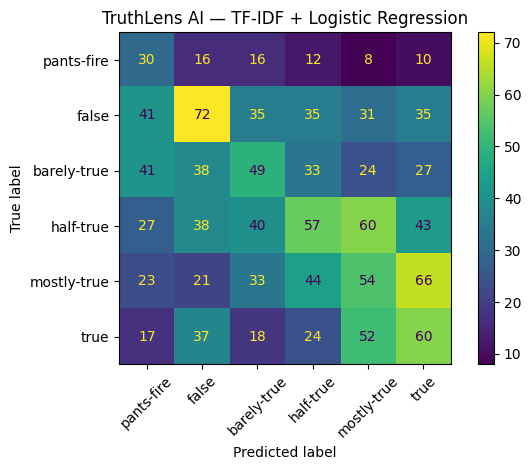

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    labels=[
        "pants-fire",
        "false",
        "barely-true",
        "half-true",
        "mostly-true",
        "true"
    ],
    xticks_rotation=45
)

plt.title("TruthLens AI — TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()

In [14]:
baseline_results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Validation Accuracy": [valid_accuracy],
    "Validation Macro F1": [valid_f1],
    "Test Accuracy": [test_accuracy],
    "Test Macro F1": [test_f1]
})

baseline_results

,Model,Validation Accuracy,Validation Macro F1,Test Accuracy,Test Macro F1
0,TF-IDF + Logistic Regression,0.246885,0.248714,0.254144,0.251652


In [15]:
from pathlib import Path

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

baseline_results.to_csv(
    RESULTS_DIR / "baseline_results.csv",
    index=False
)

print("Baseline results saved to:")
print(RESULTS_DIR / "baseline_results.csv")

Baseline results saved to:
d:\TruthLensAI\results\baseline_results.csv


In [16]:
import joblib

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(
    tfidf,
    MODELS_DIR / "tfidf_vectorizer.pkl"
)

joblib.dump(
    model,
    MODELS_DIR / "logistic_regression_baseline.pkl"
)

print("TF-IDF vectorizer saved.")
print("Logistic Regression model saved.")

TF-IDF vectorizer saved.
Logistic Regression model saved.


In [17]:
from sklearn.svm import LinearSVC

In [18]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train, y_train)

print("Linear SVM training completed.")

Linear SVM training completed.


In [19]:
svm_valid_pred = svm_model.predict(X_valid)
svm_test_pred = svm_model.predict(X_test)

print("SVM predictions generated.")

SVM predictions generated.


In [20]:
svm_valid_accuracy = accuracy_score(
    y_valid,
    svm_valid_pred
)

svm_valid_f1 = f1_score(
    y_valid,
    svm_valid_pred,
    average="macro",
    zero_division=0
)

print("SVM Validation Accuracy:", round(svm_valid_accuracy, 4))
print("SVM Validation Macro F1:", round(svm_valid_f1, 4))

SVM Validation Accuracy: 0.2531
SVM Validation Macro F1: 0.2532


In [21]:
svm_test_accuracy = accuracy_score(
    y_test,
    svm_test_pred
)

svm_test_f1 = f1_score(
    y_test,
    svm_test_pred,
    average="macro",
    zero_division=0
)

print("SVM Test Accuracy:", round(svm_test_accuracy, 4))
print("SVM Test Macro F1:", round(svm_test_f1, 4))

SVM Test Accuracy: 0.2384
SVM Test Macro F1: 0.2325


In [22]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Linear SVM"
    ],
    "Validation Accuracy": [
        valid_accuracy,
        svm_valid_accuracy
    ],
    "Validation Macro F1": [
        valid_f1,
        svm_valid_f1
    ],
    "Test Accuracy": [
        test_accuracy,
        svm_test_accuracy
    ],
    "Test Macro F1": [
        test_f1,
        svm_test_f1
    ]
})

comparison

,Model,Validation Accuracy,Validation Macro F1,Test Accuracy,Test Macro F1
0,TF-IDF + Logistic Regression,0.246885,0.248714,0.254144,0.251652
1,TF-IDF + Linear SVM,0.253115,0.253196,0.238358,0.232511


In [23]:
comparison.to_csv(
    RESULTS_DIR / "classical_model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


In [24]:
joblib.dump(
    svm_model,
    MODELS_DIR / "linear_svm_model.pkl"
)

print("SVM model saved.")

SVM model saved.
